In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!pip install -q kaggle
!kaggle datasets download -d orvile/fetal-abdominal-structures-segmentation-dataset

Dataset URL: https://www.kaggle.com/datasets/orvile/fetal-abdominal-structures-segmentation-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 1.07G/1.07G [00:09<00:00, 120MB/s]



In [ ]:
!unzip -q fetal-abdominal-structures-segmentation-dataset.zip -d dataset

In [ ]:
import os
def find_data_root(base="dataset"):
    for root, dirs, files_ in os.walk(base):
        if "IMAGES" in dirs and "ARRAY_FORMAT" in dirs:
            return root
    raise FileNotFoundError("Could not locate IMAGES/ARRAY_FORMAT folders")
BASE = find_data_root("dataset")
IMG_DIR = os.path.join(BASE, "IMAGES")
MASK_DIR = os.path.join(BASE, "ARRAY_FORMAT")
print("Data root:", BASE)
print("Num images:", len(os.listdir(IMG_DIR)))
print("Num masks:", len(os.listdir(MASK_DIR)))

Data root: dataset/Fetal Abdominal Structures Segmentation Dataset Using Ultrasonic Images/Fetal Abdominal Structures Segmentation Dataset Using Ultrasonic Images/Fetal Abdominal Structures Segmentation Dataset Using Ultrasonic Images
Num images: 1588
Num masks: 1588


In [ ]:
import numpy as np

sample_name = sorted(os.listdir(MASK_DIR))[0]
sample = np.load(os.path.join(MASK_DIR, sample_name), allow_pickle=True).item()
print("Structure keys found:", list(sample['structures'].keys()))

# >>> SET THIS after checking the printed keys above <<<
STRUCTURE_KEYS = ['artery', 'liver', 'stomach', 'vein']

Structure keys found: ['artery', 'liver', 'stomach', 'vein']


In [ ]:
import cv2
import torch
from torch.utils.data import Dataset, DataLoader, random_split

class AbdomenDataset(Dataset):
    def __init__(self, img_dir, mask_dir, structure_keys):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(img_dir))
        self.masks = sorted(os.listdir(mask_dir))
        self.structure_keys = structure_keys
        assert len(self.images) == len(self.masks), "image/mask count mismatch"

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        data = np.load(os.path.join(self.mask_dir, self.masks[idx]), allow_pickle=True).item()
        structures = data['structures']
        mask = sum(structures[k] for k in self.structure_keys)
        mask = (mask > 0).astype(np.uint8)

        image = cv2.resize(image, (256, 256), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)

        image = image / 255.0
        image = np.expand_dims(image, axis=0)
        mask = np.expand_dims(mask, axis=0)

        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)


dataset = AbdomenDataset(IMG_DIR, MASK_DIR, STRUCTURE_KEYS)
img, mask = dataset[0]
print(img.shape, mask.shape)

torch.Size([1, 256, 256]) torch.Size([1, 256, 256])


In [ ]:
def check_foreground_ratio(dataset, n_samples=50):
    total_fg, total_px = 0, 0
    for i in range(min(n_samples, len(dataset))):
        _, m = dataset[i]
        total_fg += m.sum().item()
        total_px += m.numel()
    ratio = total_fg / total_px
    print(f"Foreground pixel ratio (avg over {n_samples} samples): {ratio:.4f}")
    return ratio

check_foreground_ratio(dataset)

Foreground pixel ratio (avg over 50 samples): 0.0437


0.0436822509765625

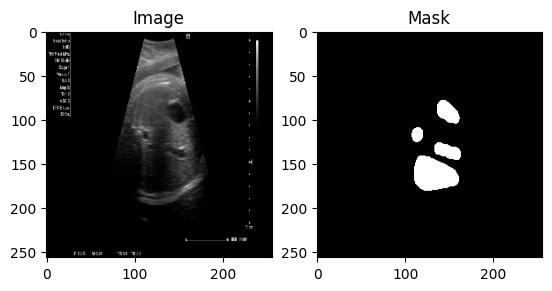

In [ ]:
import matplotlib.pyplot as plt

img, mask = dataset[0]
plt.subplot(1, 2, 1)
plt.imshow(img.squeeze(), cmap='gray')
plt.title("Image")
plt.subplot(1, 2, 2)
plt.imshow(mask.squeeze(), cmap='gray')
plt.title("Mask")
plt.show()

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.down1 = DoubleConv(1, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.down4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.conv4 = DoubleConv(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv3 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        d1 = self.down1(x)
        p1 = self.pool1(d1)
        d2 = self.down2(p1)
        p2 = self.pool2(d2)
        d3 = self.down3(p2)
        p3 = self.pool3(d3)
        d4 = self.down4(p3)
        p4 = self.pool4(d4)
        bn = self.bottleneck(p4)
        u4 = self.up4(bn)
        u4 = torch.cat([u4, d4], dim=1)
        u4 = self.conv4(u4)
        u3 = self.up3(u4)
        u3 = torch.cat([u3, d3], dim=1)
        u3 = self.conv3(u3)
        u2 = self.up2(u3)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv2(u2)
        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.conv1(u1)
        return self.final(u1)

In [ ]:
def dice_loss(pred, target):
    pred = torch.sigmoid(pred)
    smooth = 1e-6
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()
    return 1 - (2. * intersection + smooth) / (union + smooth)


def combined_loss(pred, target):
    bce = F.binary_cross_entropy_with_logits(pred, target)
    dice = dice_loss(pred, target)
    return bce + dice

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

val_size = int(0.15 * len(dataset))
train_size = len(dataset) - val_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

epochs = 20
for epoch in range(epochs):
    model.train()
    total_train_loss = 0
    for img, mask in train_loader:
        img, mask = img.to(device), mask.to(device)
        pred = model(img)
        loss = combined_loss(pred, mask)
        optimizer.zero_grad()
        loss.backward()
        total_train_loss += loss.item()

    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for img, mask in val_loader:
            img, mask = img.to(device), mask.to(device)
            pred = model(img)
            total_val_loss += combined_loss(pred, mask).item()

    print(f"Epoch {epoch+1}: train_loss={total_train_loss/len(train_loader):.4f}  "
          f"val_loss={total_val_loss/len(val_loader):.4f}")

Epoch 1: train_loss=0.9685  val_loss=0.6090
Epoch 2: train_loss=0.5439  val_loss=0.4591
Epoch 3: train_loss=0.4038  val_loss=0.3506
Epoch 4: train_loss=0.3199  val_loss=0.3057
Epoch 5: train_loss=0.2817  val_loss=0.2745
Epoch 6: train_loss=0.2591  val_loss=0.2788
Epoch 7: train_loss=0.2376  val_loss=0.2379
Epoch 8: train_loss=0.2145  val_loss=0.2301
Epoch 9: train_loss=0.2039  val_loss=0.2181
Epoch 10: train_loss=0.1908  val_loss=0.2133
Epoch 11: train_loss=0.1802  val_loss=0.2055
Epoch 12: train_loss=0.1733  val_loss=0.2094
Epoch 13: train_loss=0.1632  val_loss=0.1998
Epoch 14: train_loss=0.1531  val_loss=0.1969
Epoch 15: train_loss=0.1470  val_loss=0.1936
Epoch 16: train_loss=0.1391  val_loss=0.1905
Epoch 17: train_loss=0.1315  val_loss=0.1883
Epoch 18: train_loss=0.1249  val_loss=0.1858
Epoch 19: train_loss=0.1186  val_loss=0.1933
Epoch 20: train_loss=0.1136  val_loss=0.1883


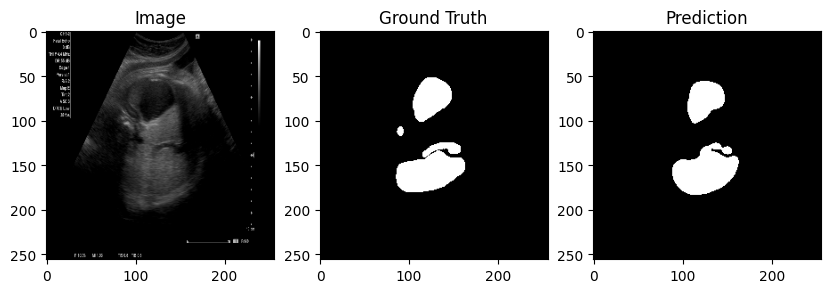

In [ ]:
model.eval()
val_img, val_mask = val_ds[0]
with torch.no_grad():
    pred = model(val_img.unsqueeze(0).to(device))
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
pred = pred.squeeze().cpu().numpy()

plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.imshow(val_img.squeeze(), cmap='gray')
plt.title("Image")
plt.subplot(1, 3, 2)
plt.imshow(val_mask.squeeze(), cmap='gray')
plt.title("Ground Truth")
plt.subplot(1, 3, 3)
plt.imshow(pred, cmap='gray')
plt.title("Prediction")
plt.show()

In [ ]:
def process_abdomen(image_path, model, device, pixel_spacing=None, ga_weeks=None):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img_resized = cv2.resize(img, (256, 256)) / 255.0
    img_tensor = torch.tensor(img_resized).unsqueeze(0).unsqueeze(0).float().to(device)
    model.eval()
    with torch.no_grad():
        pred = model(img_tensor)
        pred = torch.sigmoid(pred)
        pred = (pred > 0.5).float()
    pred = pred.squeeze().cpu().numpy()
    kernel = np.ones((7, 7), np.uint8)
    mask = cv2.morphologyEx(pred.astype(np.uint8), cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return {"error": "no contour found — model predicted an empty mask"}
    # This dataset has no dedicated abdomen-wall mask (confirmed: only
    # artery/liver/stomach/vein exist, and they're disjoint blobs). Taking
    # the convex hull over ALL detected structures approximates the outer
    # abdominal boundary, instead of keeping only the single largest organ
    # (which would just measure e.g. the liver).
    all_points = np.vstack(contours)
    cnt = cv2.convexHull(all_points)
    if len(cnt) < 5:
        return {"error": "contour too small to fit an ellipse"}
    ellipse = cv2.fitEllipse(cnt)
    (_, axes, _) = ellipse
    a, b = max(axes), min(axes)
    AC_pixels = np.pi * (a + b) / 2
    result = {"AC_pixels": AC_pixels, "mask": mask, "ellipse": ellipse}
    if pixel_spacing is not None:
        AC_mm = AC_pixels * pixel_spacing
        result["AC_mm"] = AC_mm
        if ga_weeks is not None:
            expected = 10 * ga_weeks
            if AC_mm < 0.9 * expected:
                result["assessment"] = "SGA risk"
            elif AC_mm > 1.1 * expected:
                result["assessment"] = "LGA risk"
            else:
                result["assessment"] = "Normal"
    else:
        result["AC_mm"] = None
        result["note"] = "pixel_spacing not provided — AC_mm not computed"
    return result

In [ ]:
for i in range(5):
    img_path = os.path.join(IMG_DIR, sorted(os.listdir(IMG_DIR))[i])
    out = process_abdomen(img_path, model, device)  # add real pixel_spacing/ga_weeks if you have them
    print(out.get("AC_mm", out.get("error")))
torch.save(model.state_dict(), "unet_abdomen.pth")

None
None
None
None
None


In [ ]:

WHO_AC_REFERENCE_MM = {
    # week: (p10, p50, p90)
    14: (73, 81, 89),   15: (83, 92, 100),  16: (93, 103, 112),
    17: (104, 114, 124),18: (116, 126, 136),19: (127, 138, 148),
    20: (139, 150, 161),21: (150, 162, 173),22: (162, 173, 186),
    23: (173, 185, 198),24: (184, 197, 210),25: (195, 208, 222),
    26: (205, 219, 233),27: (215, 230, 245),28: (225, 240, 256),
    29: (234, 250, 266),30: (243, 260, 277),31: (252, 269, 287),
    32: (260, 279, 298),33: (269, 288, 308),34: (277, 298, 318),
    35: (286, 307, 329),36: (294, 317, 340),37: (304, 328, 352),
    38: (313, 338, 364),39: (324, 350, 377),40: (335, 363, 391),
}
def get_ac_reference(ga_weeks):
    """Linear interpolation between reference weeks for fractional GA (e.g. 24.5)."""
    weeks = sorted(WHO_AC_REFERENCE_MM.keys())
    ga_weeks = max(weeks[0], min(weeks[-1], ga_weeks))  # clamp to table range
    lo = max(w for w in weeks if w <= ga_weeks)
    hi = min(w for w in weeks if w >= ga_weeks)
    if lo == hi:
        return WHO_AC_REFERENCE_MM[lo]
    frac = (ga_weeks - lo) / (hi - lo)
    p10 = WHO_AC_REFERENCE_MM[lo][0] + frac * (WHO_AC_REFERENCE_MM[hi][0] - WHO_AC_REFERENCE_MM[lo][0])
    p50 = WHO_AC_REFERENCE_MM[lo][1] + frac * (WHO_AC_REFERENCE_MM[hi][1] - WHO_AC_REFERENCE_MM[lo][1])
    p90 = WHO_AC_REFERENCE_MM[lo][2] + frac * (WHO_AC_REFERENCE_MM[hi][2] - WHO_AC_REFERENCE_MM[lo][2])
    return (p10, p50, p90)


def predict_development(image_path, ga_weeks, model, device, pixel_spacing):
    """
    image_path   : path to the ultrasound image
    ga_weeks     : gestational age in weeks (can be fractional, e.g. 24.5)
    pixel_spacing: mm per pixel for THIS image. Must come from real image
                   metadata (DICOM PixelSpacing tag, or scanner calibration).
                   There is no safe universal default -- ultrasound depth/zoom
                   changes this per scan. If you don't have it, this function
                   will still run but the verdict will not be trustworthy.
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img_resized = cv2.resize(img, (256, 256)) / 255.0
    img_tensor = torch.tensor(img_resized).unsqueeze(0).unsqueeze(0).float().to(device)

    model.eval()
    with torch.no_grad():
        pred = model(img_tensor)
        pred = torch.sigmoid(pred)
        pred = (pred > 0.5).float()
    pred = pred.squeeze().cpu().numpy()

    kernel = np.ones((7, 7), np.uint8)
    mask = cv2.morphologyEx(pred.astype(np.uint8), cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return {"error": "Model could not detect abdominal structures in this image. "
                          "Try a clearer scan or check the image is a valid abdomen view."}

    all_points = np.vstack(contours)
    cnt = cv2.convexHull(all_points)
    if len(cnt) < 5:
        return {"error": "Detected region too small/irregular to measure reliably."}

    ellipse = cv2.fitEllipse(cnt)
    (_, axes, _) = ellipse
    a, b = max(axes), min(axes)
    AC_pixels = np.pi * (a + b) / 2
    AC_mm = AC_pixels * pixel_spacing

    p10, p50, p90 = get_ac_reference(ga_weeks)

    if AC_mm < p10:
        verdict = "Below expected range for this gestational age (possible growth restriction / SGA)"
    elif AC_mm > p90:
        verdict = "Above expected range for this gestational age (possible LGA)"
    else:
        verdict = "Within expected range for this gestational age (normal development)"

    return {
        "AC_mm": round(AC_mm, 1),
        "gestational_age_weeks": ga_weeks,
        "expected_p10_p50_p90_mm": (round(p10, 1), round(p50, 1), round(p90, 1)),
        "verdict": verdict,
        "mask": mask,
    }

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

torch.save(model.state_dict(), "/content/drive/MyDrive/unet_abdomen.pth")

Mounted at /content/drive


In [ ]:
# %% CELL 15 — Compute real evaluation metrics on the validation set
def evaluate_model(model, val_loader, device, threshold=0.5):
    model.eval()
    dice_scores, iou_scores, pixel_accs = [], [], []
    precisions, recalls = [], []

    with torch.no_grad():
        for img, mask in val_loader:
            img, mask = img.to(device), mask.to(device)
            pred = model(img)
            pred = torch.sigmoid(pred)
            pred_bin = (pred > threshold).float()

            intersection = (pred_bin * mask).sum(dim=(1,2,3))
            union = pred_bin.sum(dim=(1,2,3)) + mask.sum(dim=(1,2,3))

            dice = (2. * intersection + 1e-6) / (union + 1e-6)
            iou = (intersection + 1e-6) / (union - intersection + 1e-6)

            correct = (pred_bin == mask).float().sum(dim=(1,2,3))
            total = torch.tensor(mask[0].numel(), dtype=torch.float32)
            pixel_acc = correct / total

            tp = intersection
            fp = (pred_bin * (1 - mask)).sum(dim=(1,2,3))
            fn = ((1 - pred_bin) * mask).sum(dim=(1,2,3))
            precision = (tp + 1e-6) / (tp + fp + 1e-6)
            recall = (tp + 1e-6) / (tp + fn + 1e-6)

            dice_scores.extend(dice.cpu().numpy())
            iou_scores.extend(iou.cpu().numpy())
            pixel_accs.extend(pixel_acc.cpu().numpy())
            precisions.extend(precision.cpu().numpy())
            recalls.extend(recall.cpu().numpy())

    results = {
        "Dice Score":     np.mean(dice_scores),
        "IoU":            np.mean(iou_scores),
        "Pixel Accuracy": np.mean(pixel_accs),
        "Precision":      np.mean(precisions),
        "Recall":         np.mean(recalls),
    }

    for k, v in results.items():
        print(f"{k}: {v:.4f}")

    return results


metrics = evaluate_model(model, val_loader, device)

Dice Score: 0.8641
IoU: 0.7647
Pixel Accuracy: 0.9868
Precision: 0.8689
Recall: 0.8658
